# Proyecto de Minería de Datos
## Modelo de Clasificación con Regresión Logística

**Objetivo:** predecir el resultado de un partido de fútbol.

**Variable objetivo:** `resultado_real`

- `S` = victoria del equipo local
- `H` = empate
- `A` = victoria del equipo visitante

En este notebook se busca que cada sección sea fácil de entender. Por eso se utilizan gráficos de barras para resumir los resultados principales.

> **Importante:** este notebook solo lee los datos; no modifica ni sobrescribe los archivos CSV del proyecto.


## 1. ¿Qué queremos predecir?

Queremos que el modelo responda una pregunta sencilla:

> **¿El partido terminará en victoria local, empate o victoria visitante?**

Por eso nuestra variable dependiente es `resultado_real`.

Las demás columnas que utilizaremos serán las variables independientes, es decir, la información que el modelo analizará para intentar predecir el resultado.


In [1]:
# ==========================================
# 2. IMPORTAR LIBRERÍAS
# ==========================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### ¿Para qué sirven estas librerías?

- **Pandas:** leer y manipular el dataset.
- **NumPy:** operaciones numéricas.
- **Matplotlib:** crear gráficos.
- **SimpleImputer:** rellenar valores faltantes.
- **StandardScaler:** poner las variables numéricas en escalas comparables.
- **OneHotEncoder:** convertir variables categóricas en valores que el modelo pueda utilizar.
- **Pipeline:** unir limpieza, transformación y modelo en un solo flujo.
- **LogisticRegression:** algoritmo que realizará la clasificación.
- **GridSearchCV:** probar distintas configuraciones y elegir la mejor.
- **TimeSeriesSplit:** validar respetando el orden temporal de los partidos.


## 2. Carga del dataset

Se utiliza el archivo:

`Data/raw/predicciones_personas.csv`

El notebook localiza automáticamente la raíz del proyecto para evitar problemas de rutas.


In [2]:
def encontrar_raiz_proyecto():
    actual = Path.cwd().resolve()

    for carpeta in [actual, *actual.parents]:
        if (carpeta / "Data").exists() and (carpeta / "Codigo").exists():
            return carpeta

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto. "
        "Ejecuta el notebook dentro de Grupo_Patitogit."
    )

RAIZ = encontrar_raiz_proyecto()

RUTA_DATOS = (
    RAIZ
    / "Data"
    / "raw"
    / "predicciones_personas.csv"
)

if not RUTA_DATOS.exists():
    raise FileNotFoundError(f"No existe el archivo: {RUTA_DATOS}")

datos = pd.read_csv(RUTA_DATOS)

print("Dataset cargado correctamente.")
print("Cantidad de partidos:", len(datos))
print("Cantidad de variables:", len(datos.columns))


Dataset cargado correctamente.
Cantidad de partidos: 11417
Cantidad de variables: 65


In [3]:
# Mostrar las primeras filas para conocer la estructura
datos.head()


,Votes_for_Home,Votes_for_Draw,Votes_for_Away,Weekday,Day,Month,Year,Hour,Minute,Total_Bettors,...,Country_2,Detail_H2H,Indices_home,Indices_draw,Indices_away,Results_1,Results_2,resultado_real,prediccion_personas,acierto_personas
0,18,14,19,Thu,3,1,2019,21,0,64512,...,england,3/A/D/0/0_6/H/L/1/2_9/H/L/1/2_10/A/L/0/3_12/A/...,9_10_13_19_21_52_44_46_24_77_82_87_88_89_90_10...,6_14_50_51_25_38_43_78_85_86_92_93_94_104,11_12_15_16_27_30_35_37_39_54_81_84_96_99_102_...,2,1,S,A,False
1,3,1,45,Wed,2,1,2019,21,0,25872,...,england,3/A/L/2/3_11/H/W/1/0_14/A/L/1/4_37/H/D/3/3_41/...,21_42_44,104,48_6_9_10_11_12_14_15_16_19_51_52_53_26_27_28_...,0,2,A,A,True
2,5,1,42,Sat,12,1,2019,16,0,22624,...,england,5/A/L/0/1_9/A/L/0/4_14/H/L/1/5_84/A/L/1/6_90/H...,13_14_21_42_100,93,3_6_8_9_10_11_12_15_16_50_18_51_52_29_30_35_36...,0,1,A,A,True
3,46,0,1,Sat,19,1,2019,16,0,22400,...,england,6/A/L/2/3_9/A/L/0/1_11/H/W/2/0_15/H/W/1/0,2_3_6_9_10_11_12_13_14_16_50_18_19_21_52_26_27...,NaN,36,2,1,S,S,True
4,44,0,3,Sat,12,1,2019,18,30,16576,...,england,5/A/W/2/1_9/A/L/0/3_12/H/W/3/0_14/H/W/3/1_36/H...,6_8_10_11_12_14_15_16_50_18_51_21_52_27_29_35_...,NaN,30_77_100,2,1,S,S,True


## 3. Distribución de la variable objetivo

Antes de entrenar el modelo conviene saber cuántos partidos corresponden a cada resultado.

Un gráfico de barras es adecuado porque `resultado_real` es una variable categórica.


,Cantidad,Porcentaje (%)
resultado_real,,
S,5316,46.56
H,2610,22.86
A,3491,30.58


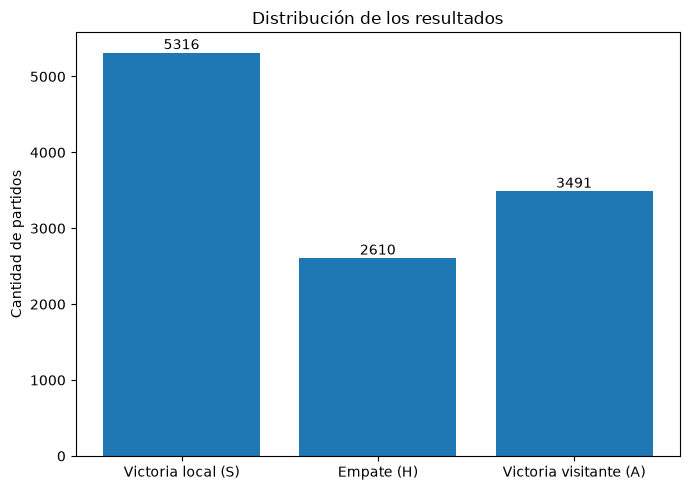

In [4]:
VARIABLE_OBJETIVO = "resultado_real"

if VARIABLE_OBJETIVO not in datos.columns:
    raise ValueError(
        f"No existe la variable objetivo '{VARIABLE_OBJETIVO}' en el dataset."
    )

orden_clases = ["S", "H", "A"]

conteo_clases = (
    datos[VARIABLE_OBJETIVO]
    .value_counts()
    .reindex(orden_clases)
    .fillna(0)
)

porcentaje_clases = (
    conteo_clases / conteo_clases.sum() * 100
).round(2)

resumen_clases = pd.DataFrame({
    "Cantidad": conteo_clases,
    "Porcentaje (%)": porcentaje_clases
})

display(resumen_clases)

plt.figure(figsize=(7, 5))

barras = plt.bar(
    ["Victoria local (S)", "Empate (H)", "Victoria visitante (A)"],
    conteo_clases.values
)

plt.title("Distribución de los resultados")
plt.ylabel("Cantidad de partidos")

for barra, cantidad in zip(barras, conteo_clases.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        str(int(cantidad)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


### ¿Cómo se interpreta?

La barra más alta representa el resultado que aparece con mayor frecuencia.

Si una clase aparece mucho más que las otras, existe **desbalance de clases**. Esto es importante porque un modelo podría aprender a favorecer el resultado más común.


## 4. Datos faltantes

El dataset contiene columnas con valores nulos. En lugar de borrar una gran cantidad de partidos, el modelo utilizará imputación para completar los valores faltantes durante el entrenamiento.


,Valores faltantes,Porcentaje (%)
Indices_draw,8581,75.16
Jumps,5686,49.80
Avrage_FT_Goal,5686,49.80
Number_of_H2H_matches,5686,49.80
Average_HT_Goal,5686,49.80
Team_1_Found,5686,49.80
Team_2_Found,5686,49.80
Rank_1,5686,49.80
League_type_country,5686,49.80
Detail_H2H,5686,49.80


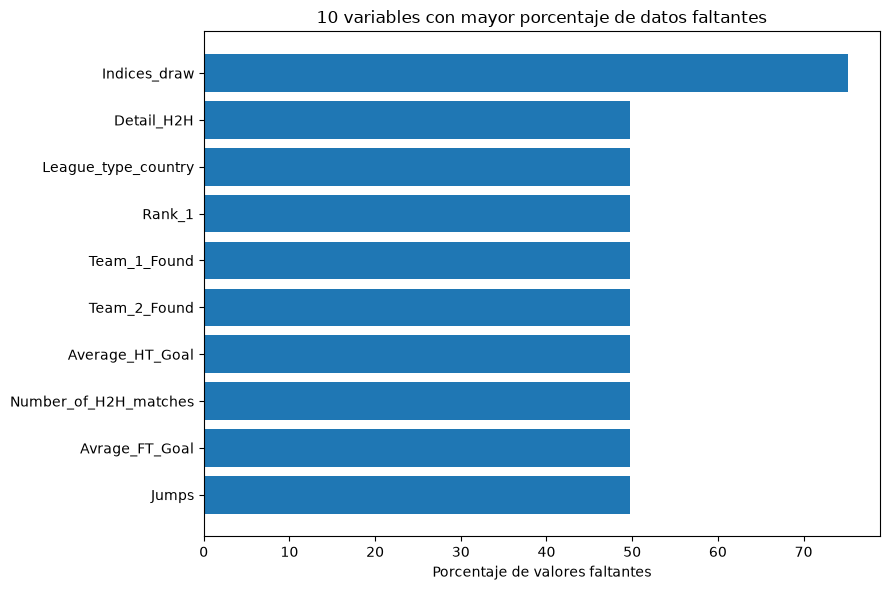

In [5]:
faltantes = datos.isna().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

resumen_faltantes = pd.DataFrame({
    "Valores faltantes": faltantes,
    "Porcentaje (%)": (faltantes / len(datos) * 100).round(2)
})

display(resumen_faltantes.head(15))

top_faltantes = resumen_faltantes.head(10).sort_values(
    "Porcentaje (%)"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_faltantes.index,
    top_faltantes["Porcentaje (%)"]
)

plt.xlabel("Porcentaje de valores faltantes")
plt.title("10 variables con mayor porcentaje de datos faltantes")
plt.tight_layout()
plt.show()


### ¿Qué hará el modelo con los nulos?

- En variables numéricas se utilizará la **mediana**.
- En variables categóricas se utilizará el **valor más frecuente**.

Esto se hará dentro del `Pipeline`, evitando modificar directamente el dataset original.


## 5. Variables independientes

Se seleccionan variables relacionadas con:

- votos y porcentajes de los participantes;
- cantidad de participantes;
- posición de los equipos;
- puntos y partidos jugados;
- goles anotados y recibidos;
- diferencia de goles;
- cuotas;
- día de la semana.

No se utilizan `Results_1`, `Results_2`, `resultado_real`, `prediccion_personas` ni `acierto_personas` como entradas porque contienen el resultado final o información derivada directamente de él. Utilizarlas sería darle al modelo parte de la respuesta.


In [6]:
variables_numericas = [
    "Votes_for_Home",
    "Votes_for_Draw",
    "Votes_for_Away",
    "Total_Bettors",
    "Bet_Perc_on_Home",
    "Bet_Perc_on_Draw",
    "Bet_Perc_on_Away",
    "League_Rank_1",
    "League_Rank_2",
    "Games_played_1",
    "Games_played_2",
    "Points_1",
    "Points_2",
    "Goals_Scored_1",
    "Goals_Scored_2",
    "Goals_Rec_1",
    "Goal_Rec_2",
    "Goals_Diff_1",
    "Goals_Diff_2",
    "Odds_Home",
    "Odds_Draw",
    "Odds_Away",
]

variables_categoricas = [
    "Weekday",
]

variables_prohibidas = {
    "Results_1",
    "Results_2",
    "resultado_real",
    "prediccion_personas",
    "acierto_personas",
}

assert not variables_prohibidas.intersection(
    variables_numericas + variables_categoricas
), "Se detectó una variable que provoca fuga de información."

variables_solicitadas = variables_numericas + variables_categoricas
faltan = [c for c in variables_solicitadas if c not in datos.columns]

if faltan:
    raise ValueError(
        "Faltan estas columnas en el dataset: "
        + ", ".join(faltan)
    )

print("Variables numéricas seleccionadas:", len(variables_numericas))
print("Variables categóricas seleccionadas:", len(variables_categoricas))
print("Variable objetivo:", VARIABLE_OBJETIVO)


Variables numéricas seleccionadas: 22
Variables categóricas seleccionadas: 1
Variable objetivo: resultado_real


## 6. División en entrenamiento y prueba

Los partidos se ordenan cronológicamente.

- **80 %** se utiliza para entrenar.
- **20 %** se reserva para probar el modelo.

La idea es sencilla: el modelo aprende con partidos anteriores y después se prueba con partidos posteriores.


Total: 11417
Entrenamiento: 9133
Prueba: 2284


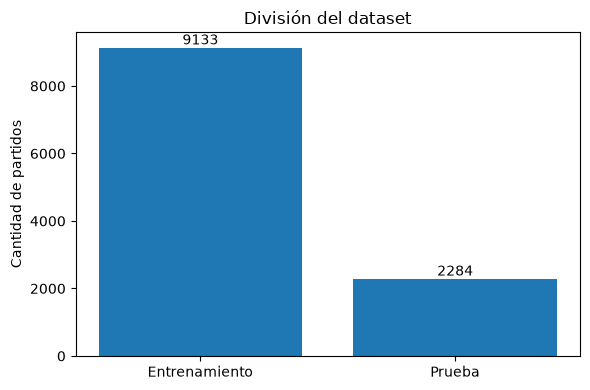

In [7]:
trabajo = datos.copy()

trabajo = trabajo.dropna(
    subset=[VARIABLE_OBJETIVO]
).copy()

if {"Year", "Month", "Day"}.issubset(trabajo.columns):
    trabajo["fecha_modelo"] = pd.to_datetime(
        {
            "year": trabajo["Year"],
            "month": trabajo["Month"],
            "day": trabajo["Day"],
        },
        errors="coerce",
    )

    trabajo = trabajo.sort_values(
        by="fecha_modelo",
        na_position="last"
    ).reset_index(drop=True)

trabajo["Weekday"] = trabajo["Weekday"].astype("string")

X = trabajo[
    variables_numericas + variables_categoricas
].copy()

y = trabajo[VARIABLE_OBJETIVO].copy()

punto_division = int(len(trabajo) * 0.80)

X_entrenamiento = X.iloc[:punto_division].copy()
X_prueba = X.iloc[punto_division:].copy()

y_entrenamiento = y.iloc[:punto_division].copy()
y_prueba = y.iloc[punto_division:].copy()

cantidades = [
    len(X_entrenamiento),
    len(X_prueba)
]

print("Total:", len(trabajo))
print("Entrenamiento:", len(X_entrenamiento))
print("Prueba:", len(X_prueba))

plt.figure(figsize=(6, 4))

barras = plt.bar(
    ["Entrenamiento", "Prueba"],
    cantidades
)

plt.title("División del dataset")
plt.ylabel("Cantidad de partidos")

for barra, cantidad in zip(barras, cantidades):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        str(cantidad),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


## 7. Limpieza, codificación y escalado

El flujo será:

**Datos → completar nulos → escalar/codificar → Regresión Logística**

- Las variables numéricas se completan con la mediana y se escalan.
- `Weekday` se completa con el valor más frecuente y se transforma mediante `OneHotEncoder`.
- Todo se integra dentro de un `Pipeline`.


In [8]:
pipeline_numerico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
    ]
)

pipeline_categorico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="most_frequent")),
        (
            "codificador",
            OneHotEncoder(handle_unknown="ignore"),
        ),
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico,
            variables_numericas,
        ),
        (
            "categoricas",
            pipeline_categorico,
            variables_categoricas,
        ),
    ]
)

modelo_inicial = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        (
            "modelo",
            LogisticRegression(
                max_iter=3000,
                random_state=42,
            ),
        ),
    ]
)

print("Pipeline creado correctamente.")


Pipeline creado correctamente.


## 8. Entrenamiento del modelo inicial

Primero se entrena una Regresión Logística con una configuración inicial.

Después se comparará con una versión ajustada mediante búsqueda de hiperparámetros.


In [9]:
modelo_inicial.fit(
    X_entrenamiento,
    y_entrenamiento
)

predicciones_iniciales = modelo_inicial.predict(
    X_prueba
)

probabilidades_iniciales = modelo_inicial.predict_proba(
    X_prueba
)

print("Modelo inicial entrenado correctamente.")


Modelo inicial entrenado correctamente.


## 9. Métricas del modelo inicial

Se utilizan cuatro métricas principales:

- **Accuracy:** de todos los partidos, cuántos acertó.
- **Precision:** cuando el modelo predice una clase, qué tan seguido tiene razón.
- **Recall:** de los casos reales de cada clase, cuántos logra encontrar.
- **F1:** combina precision y recall.

Para facilitar la lectura, se muestran en un gráfico de barras.


,Métrica,Porcentaje
0,Accuracy,53.11
1,Precision,48.60
2,Recall,45.04
3,F1,40.57


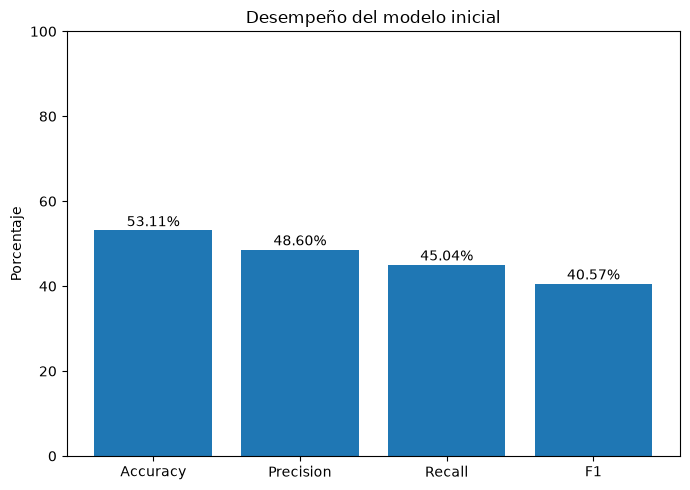

In [10]:
accuracy_inicial = accuracy_score(
    y_prueba,
    predicciones_iniciales
)

precision_inicial = precision_score(
    y_prueba,
    predicciones_iniciales,
    average="macro",
    zero_division=0,
)

recall_inicial = recall_score(
    y_prueba,
    predicciones_iniciales,
    average="macro",
    zero_division=0,
)

f1_inicial = f1_score(
    y_prueba,
    predicciones_iniciales,
    average="macro",
    zero_division=0,
)

metricas_iniciales = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Valor": [
        accuracy_inicial,
        precision_inicial,
        recall_inicial,
        f1_inicial
    ]
})

metricas_iniciales["Porcentaje"] = (
    metricas_iniciales["Valor"] * 100
).round(2)

display(metricas_iniciales[["Métrica", "Porcentaje"]])

plt.figure(figsize=(7, 5))

barras = plt.bar(
    metricas_iniciales["Métrica"],
    metricas_iniciales["Porcentaje"]
)

plt.ylim(0, 100)
plt.ylabel("Porcentaje")
plt.title("Desempeño del modelo inicial")

for barra, valor in zip(
    barras,
    metricas_iniciales["Porcentaje"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{valor:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


### Lectura rápida

Si `Accuracy = 50 %`, significa que el modelo acierta aproximadamente **5 de cada 10 partidos**.

Las otras tres métricas sirven para comprobar que el modelo no esté funcionando bien únicamente para una de las clases.


## 10. Ajuste de hiperparámetros

La Regresión Logística tiene configuraciones que pueden cambiar su rendimiento.

Se prueban distintos valores de:

- `C`: controla la regularización.
- `class_weight`: permite compensar el desbalance de clases.

`GridSearchCV` prueba las combinaciones y selecciona la que obtiene mejor `F1 macro`.


In [11]:
parametros = {
    "modelo__C": [
        0.01,
        0.1,
        1,
        10,
        100,
    ],
    "modelo__class_weight": [
        None,
        "balanced",
    ],
}

validacion_temporal = TimeSeriesSplit(
    n_splits=5
)

busqueda = GridSearchCV(
    estimator=modelo_inicial,
    param_grid=parametros,
    scoring="f1_macro",
    cv=validacion_temporal,
    n_jobs=-1,
    refit=True,
)

busqueda.fit(
    X_entrenamiento,
    y_entrenamiento
)

print("Mejores parámetros encontrados:")
print(busqueda.best_params_)

print(
    "Mejor F1 macro durante la validación:",
    round(busqueda.best_score_, 4),
)


Mejores parámetros encontrados:
{'modelo__C': 0.01, 'modelo__class_weight': 'balanced'}
Mejor F1 macro durante la validación: 0.4782


## 11. Evaluación del modelo ajustado

Ahora se evalúa la mejor configuración encontrada por `GridSearchCV`.

Primero calculamos sus métricas y después las comparamos visualmente con el modelo inicial.


,Métrica,Inicial (%),Ajustado (%)
0,Accuracy,53.11,50.39
1,Precision,48.60,47.77
2,Recall,45.04,47.85
3,F1,40.57,47.76


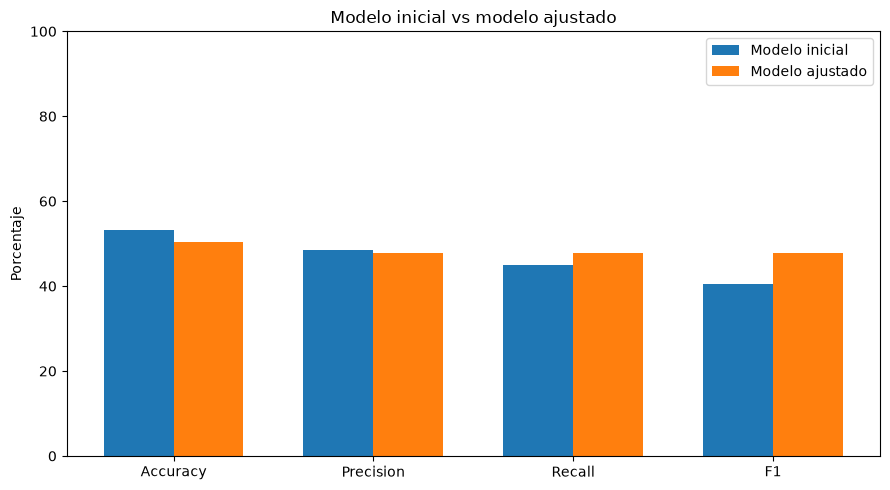

In [12]:
mejor_modelo = busqueda.best_estimator_

predicciones_ajustadas = mejor_modelo.predict(
    X_prueba
)

probabilidades_ajustadas = mejor_modelo.predict_proba(
    X_prueba
)

accuracy_ajustado = accuracy_score(
    y_prueba,
    predicciones_ajustadas
)

precision_ajustado = precision_score(
    y_prueba,
    predicciones_ajustadas,
    average="macro",
    zero_division=0,
)

recall_ajustado = recall_score(
    y_prueba,
    predicciones_ajustadas,
    average="macro",
    zero_division=0,
)

f1_ajustado = f1_score(
    y_prueba,
    predicciones_ajustadas,
    average="macro",
    zero_division=0,
)

comparacion_metricas = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Inicial": [
        accuracy_inicial,
        precision_inicial,
        recall_inicial,
        f1_inicial
    ],
    "Ajustado": [
        accuracy_ajustado,
        precision_ajustado,
        recall_ajustado,
        f1_ajustado
    ]
})

comparacion_metricas["Inicial (%)"] = (
    comparacion_metricas["Inicial"] * 100
).round(2)

comparacion_metricas["Ajustado (%)"] = (
    comparacion_metricas["Ajustado"] * 100
).round(2)

display(
    comparacion_metricas[
        ["Métrica", "Inicial (%)", "Ajustado (%)"]
    ]
)

x = np.arange(len(comparacion_metricas))
ancho = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - ancho / 2,
    comparacion_metricas["Inicial (%)"],
    width=ancho,
    label="Modelo inicial"
)

plt.bar(
    x + ancho / 2,
    comparacion_metricas["Ajustado (%)"],
    width=ancho,
    label="Modelo ajustado"
)

plt.xticks(
    x,
    comparacion_metricas["Métrica"]
)

plt.ylim(0, 100)
plt.ylabel("Porcentaje")
plt.title("Modelo inicial vs modelo ajustado")
plt.legend()
plt.tight_layout()
plt.show()


### ¿Qué buscamos en este gráfico?

Si las barras del modelo ajustado son más altas, significa que el ajuste de hiperparámetros mejoró el desempeño.

Si prácticamente no cambian, el ajuste tuvo poco efecto.


## 12. Rendimiento por cada tipo de resultado

En vez de utilizar una matriz de confusión, mostramos un gráfico de barras con `precision`, `recall` y `F1` para cada clase.

Esto permite responder fácilmente:

- ¿El modelo funciona mejor para victoria local?
- ¿Tiene problemas con los empates?
- ¿Cómo se comporta con las victorias visitantes?


,Clase,Precision,Recall,F1
0,Victoria visitante (A),49.29,51.55,50.40
1,Empate (H),30.94,33.45,32.15
2,Victoria local (S),63.09,58.54,60.73


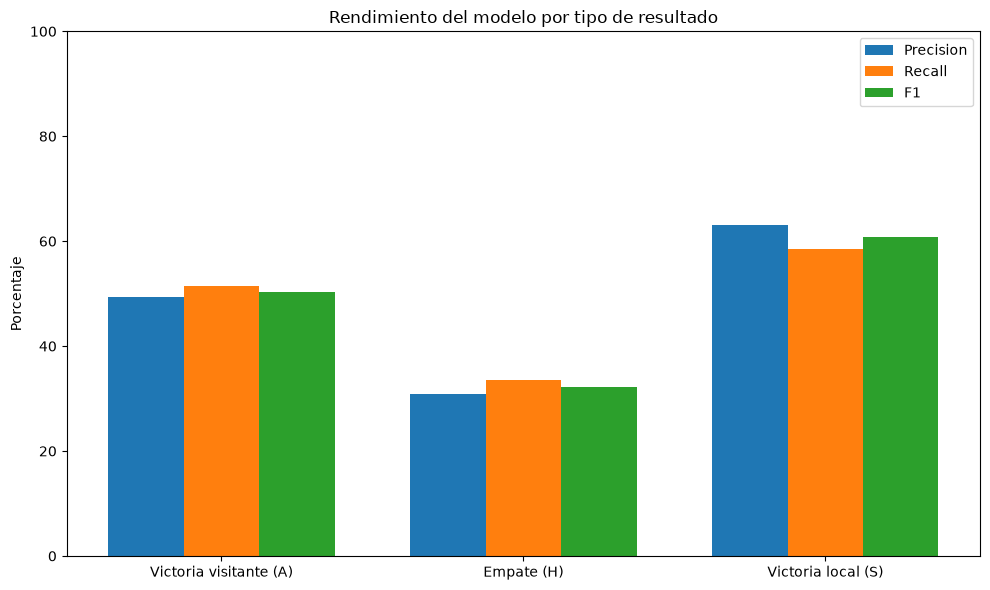

In [13]:
reporte_clases = classification_report(
    y_prueba,
    predicciones_ajustadas,
    labels=["A", "H", "S"],
    output_dict=True,
    zero_division=0
)

metricas_clases = pd.DataFrame({
    "Clase": [
        "Victoria visitante (A)",
        "Empate (H)",
        "Victoria local (S)"
    ],
    "Precision": [
        reporte_clases["A"]["precision"] * 100,
        reporte_clases["H"]["precision"] * 100,
        reporte_clases["S"]["precision"] * 100,
    ],
    "Recall": [
        reporte_clases["A"]["recall"] * 100,
        reporte_clases["H"]["recall"] * 100,
        reporte_clases["S"]["recall"] * 100,
    ],
    "F1": [
        reporte_clases["A"]["f1-score"] * 100,
        reporte_clases["H"]["f1-score"] * 100,
        reporte_clases["S"]["f1-score"] * 100,
    ],
})

display(metricas_clases.round(2))

x = np.arange(len(metricas_clases))
ancho = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - ancho,
    metricas_clases["Precision"],
    width=ancho,
    label="Precision"
)

plt.bar(
    x,
    metricas_clases["Recall"],
    width=ancho,
    label="Recall"
)

plt.bar(
    x + ancho,
    metricas_clases["F1"],
    width=ancho,
    label="F1"
)

plt.xticks(
    x,
    metricas_clases["Clase"]
)

plt.ylim(0, 100)
plt.ylabel("Porcentaje")
plt.title("Rendimiento del modelo por tipo de resultado")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretación del gráfico por clases

La clase que tenga barras más altas es la que el modelo reconoce mejor.

Si una clase, por ejemplo `H` (empate), tiene barras mucho más bajas, significa que el modelo tiene más dificultad para identificar ese resultado.


## 13. Curva ROC multiclase

La actividad también pide una curva ROC.

Esta gráfica mide qué tan bien logra separar el modelo las tres clases.

Como referencia:

- alrededor de **0.50**: separación muy débil;
- alrededor de **0.60–0.70**: separación moderada;
- valores más cercanos a **1.00**: mejor capacidad de separación.


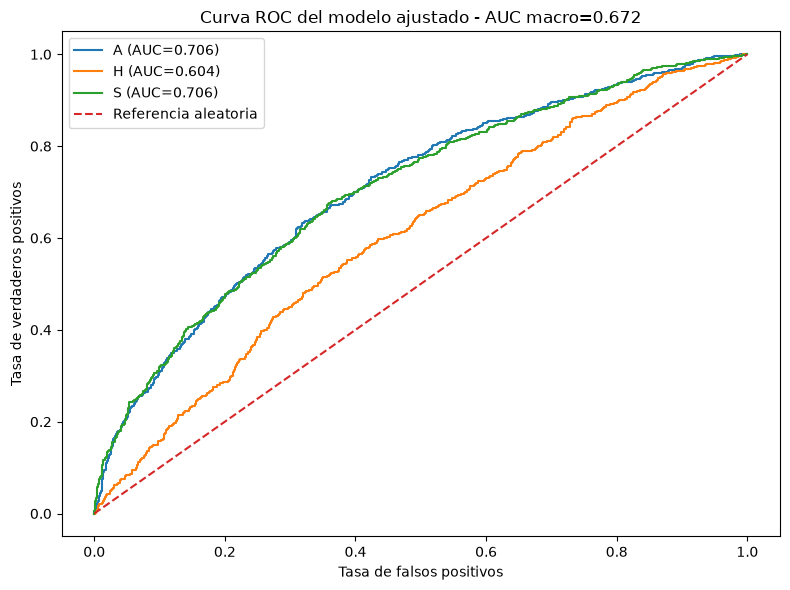

In [14]:
clases_ajustadas = mejor_modelo.named_steps["modelo"].classes_

y_prueba_bin_ajustada = label_binarize(
    y_prueba,
    classes=clases_ajustadas,
)

auc_macro_ajustado = roc_auc_score(
    y_prueba_bin_ajustada,
    probabilidades_ajustadas,
    average="macro",
    multi_class="ovr",
)

plt.figure(figsize=(8, 6))

for i, clase in enumerate(clases_ajustadas):
    fpr, tpr, _ = roc_curve(
        y_prueba_bin_ajustada[:, i],
        probabilidades_ajustadas[:, i],
    )

    auc_clase = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{clase} (AUC={auc_clase:.3f})",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Referencia aleatoria",
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title(
    f"Curva ROC del modelo ajustado - AUC macro={auc_macro_ajustado:.3f}"
)
plt.legend()
plt.tight_layout()
plt.show()


## 14. Comparación contra referencias simples

Para saber si el modelo realmente aporta algo, se compara con:

- **Baseline:** predecir siempre la clase más frecuente.
- **Personas:** predicción mayoritaria de los participantes.
- **Regresión Logística inicial.**
- **Regresión Logística ajustada.**

Este es uno de los gráficos más importantes porque permite explicar rápidamente si el modelo mejora o no las alternativas existentes.


,Método,Accuracy (%)
1,Regresión inicial,53.11
3,Predicción de personas,51.49
2,Regresión ajustada,50.39
0,Baseline,46.15


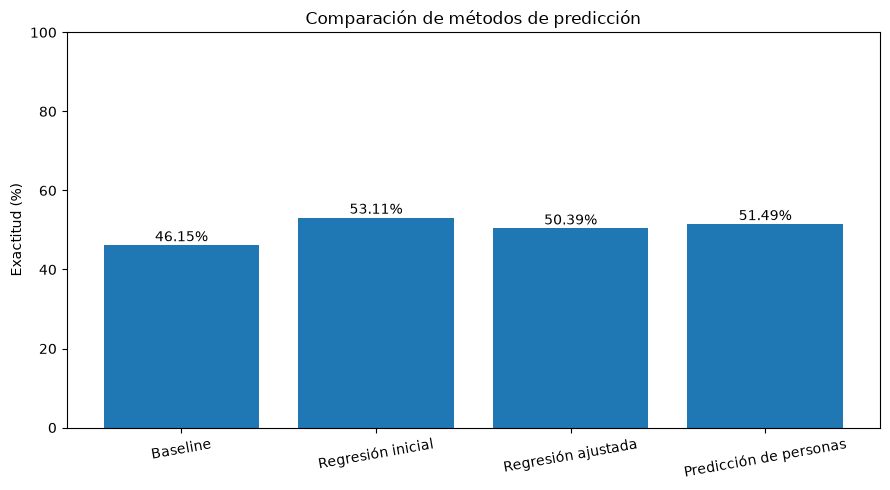

In [15]:
clase_mayoritaria = y_entrenamiento.mode().iloc[0]

prediccion_mayoritaria = np.repeat(
    clase_mayoritaria,
    len(y_prueba),
)

accuracy_baseline = accuracy_score(
    y_prueba,
    prediccion_mayoritaria,
)

accuracy_personas = None

if "prediccion_personas" in trabajo.columns:
    pred_personas_prueba = (
        trabajo["prediccion_personas"]
        .iloc[punto_division:]
        .reset_index(drop=True)
    )

    y_prueba_personas = (
        y_prueba
        .reset_index(drop=True)
    )

    mascara = pred_personas_prueba.notna()

    if mascara.any():
        accuracy_personas = accuracy_score(
            y_prueba_personas[mascara],
            pred_personas_prueba[mascara],
        )

resultados = pd.DataFrame({
    "Método": [
        "Baseline",
        "Regresión inicial",
        "Regresión ajustada",
    ],
    "Accuracy": [
        accuracy_baseline,
        accuracy_inicial,
        accuracy_ajustado,
    ],
})

if accuracy_personas is not None:
    resultados.loc[len(resultados)] = [
        "Predicción de personas",
        accuracy_personas,
    ]

resultados["Accuracy (%)"] = (
    resultados["Accuracy"] * 100
).round(2)

display(
    resultados[
        ["Método", "Accuracy (%)"]
    ].sort_values(
        "Accuracy (%)",
        ascending=False
    )
)

plt.figure(figsize=(9, 5))

barras = plt.bar(
    resultados["Método"],
    resultados["Accuracy (%)"]
)

plt.ylim(0, 100)
plt.ylabel("Exactitud (%)")
plt.title("Comparación de métodos de predicción")

for barra, valor in zip(
    barras,
    resultados["Accuracy (%)"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{valor:.2f}%",
        ha="center"
    )

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 15. Interpretación en palabras simples

La siguiente celda convierte las métricas en frases fáciles de explicar durante una exposición.


In [16]:
print("INTERPRETACIÓN DEL MODELO")
print("=========================")

print(
    f"1. De cada 100 partidos, el modelo ajustado acierta "
    f"aproximadamente {accuracy_ajustado * 100:.2f}."
)

print(
    f"2. Su precisión promedio entre las tres clases es "
    f"{precision_ajustado * 100:.2f}%."
)

print(
    f"3. Logra detectar aproximadamente "
    f"{recall_ajustado * 100:.2f}% de los casos reales de cada clase, "
    f"en promedio."
)

print(
    f"4. El F1 macro es {f1_ajustado * 100:.2f}%, "
    f"lo que resume el equilibrio entre precision y recall."
)

print(
    f"5. El ROC-AUC macro es {auc_macro_ajustado:.3f}, "
    f"por lo que el modelo sí distingue patrones, "
    f"aunque todavía tiene margen de mejora."
)

diferencia_baseline = (
    accuracy_ajustado - accuracy_baseline
) * 100

print(
    f"6. Frente al baseline, el modelo cambia el resultado en "
    f"{diferencia_baseline:+.2f} puntos porcentuales."
)

if accuracy_personas is not None:
    diferencia_personas = (
        accuracy_ajustado - accuracy_personas
    ) * 100

    print(
        f"7. Frente a la predicción de las personas, la diferencia es "
        f"{diferencia_personas:+.2f} puntos porcentuales."
    )

mejor_clase = (
    metricas_clases
    .set_index("Clase")["F1"]
    .idxmax()
)

peor_clase = (
    metricas_clases
    .set_index("Clase")["F1"]
    .idxmin()
)

print(
    f"8. La clase que mejor reconoce el modelo es: {mejor_clase}."
)

print(
    f"9. La clase que más dificultad presenta es: {peor_clase}."
)


INTERPRETACIÓN DEL MODELO
1. De cada 100 partidos, el modelo ajustado acierta aproximadamente 50.39.
2. Su precisión promedio entre las tres clases es 47.77%.
3. Logra detectar aproximadamente 47.85% de los casos reales de cada clase, en promedio.
4. El F1 macro es 47.76%, lo que resume el equilibrio entre precision y recall.
5. El ROC-AUC macro es 0.672, por lo que el modelo sí distingue patrones, aunque todavía tiene margen de mejora.
6. Frente al baseline, el modelo cambia el resultado en +4.25 puntos porcentuales.
7. Frente a la predicción de las personas, la diferencia es -1.09 puntos porcentuales.
8. La clase que mejor reconoce el modelo es: Victoria local (S).
9. La clase que más dificultad presenta es: Empate (H).


## 16. Conclusión

La Regresión Logística obtuvo una exactitud de 50,39%, por lo que acierta aproximadamente 5 de cada 10 partidos.

El modelo superó al baseline de clase mayoritaria en 4,25 puntos porcentuales, por lo que logró aprender patrones útiles de los datos.

Sin embargo, quedó 1,09 puntos porcentuales por debajo de la predicción mayoritaria de las personas.

El F1 macro fue de 47,76% y el ROC-AUC macro de 0,672, lo que muestra que el modelo tiene una capacidad moderada para diferenciar entre victoria local, empate y victoria visitante.

En conclusión, la Regresión Logística funciona como un modelo base útil, pero todavía necesita mejores variables o ajustes para mejorar su capacidad de predicción.